### Obtain

In [184]:
#polars
#fastexcel
#numpy
#seaborn
#matplotib
#scikit-learn
#pandas
#pyarrow

In [185]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

In [186]:
df_roturas = pl.read_excel(
    "datasets/02_ROTURAS_RED_PRIMARIA_SECUNDARIA_PIURA.xlsx",
    sheet_name="ROTURAS_RED_PRIMARIA",
)
df_fugas = pl.read_excel(
    "datasets/02_ROTURAS_RED_PRIMARIA_SECUNDARIA_PIURA.xlsx",
    sheet_name="FUGAS_RED_SECUNDARIA",
)
df_redes = pl.read_excel("datasets/03_REDES_CONEXIONES_PIURA.xlsx")
df_cau = pl.read_excel("datasets/01_BASE_CAUDALES_SECTORES_PIURA.xlsx")

## Reto 1

###  Inconsistencias geográficas

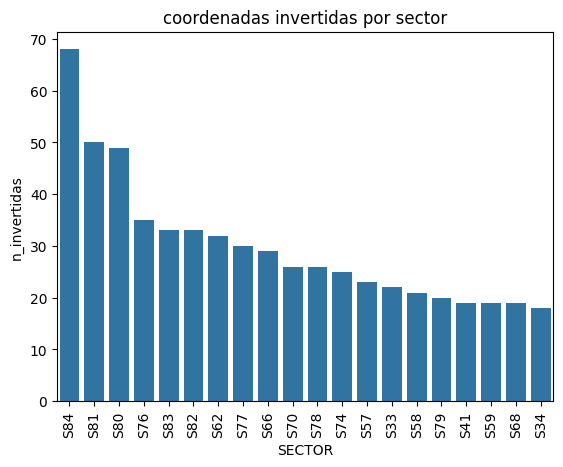

In [187]:
# conteo
inv_prim = df_roturas.filter(pl.col('latitud') < -20).group_by('SECTOR').agg(pl.len().alias('n_invertidas')).with_columns(pl.lit('roturas').alias('tipo'))
inv_sec = df_fugas.filter(pl.col('latitud') < -20).group_by('SECTOR').agg(pl.len().alias('n_invertidas')).with_columns(pl.lit('fugas').alias('tipo'))
df_coord_inv = pl.concat([inv_prim, inv_sec]).sort('n_invertidas', descending=True)

# grafico
sns.barplot(data=df_coord_inv.head(20).to_pandas(), x='SECTOR', y='n_invertidas')
plt.title('coordenadas invertidas por sector')
plt.xticks(rotation=90)
plt.show()

In [188]:
# correccion
df_roturas = df_roturas.with_columns([
    pl.when(pl.col("latitud") < -20).then(pl.col("longitud")).otherwise(pl.col("latitud")).alias("lat_new"),
    pl.when(pl.col("latitud") < -20).then(pl.col("latitud")).otherwise(pl.col("longitud")).alias("lon_new")
]).drop(["latitud", "longitud"]).rename({"lat_new": "latitud", "lon_new": "longitud"})

df_fugas = df_fugas.with_columns([
    pl.when(pl.col("latitud") < -20).then(pl.col("longitud")).otherwise(pl.col("latitud")).alias("lat_new"),
    pl.when(pl.col("latitud") < -20).then(pl.col("latitud")).otherwise(pl.col("longitud")).alias("lon_new")
]).drop(["latitud", "longitud"]).rename({"lat_new": "latitud", "lon_new": "longitud"})

### Sobreregistro de datos

In [189]:
df_roturas = df_roturas.unique(subset=["CONEXION", "CATEGORIA", "fecha_inicio"])
df_fugas = df_fugas.unique(subset=["CONEXION", "CATEGORIA", "fecha_inicio"])

# tabla observaciones unicas
obs_unicas = pl.DataFrame({
    "tipo": ["roturas", "fugas"],
    "conteo_unico": [df_roturas.height, df_fugas.height]
})

## Reto 2: Consolidación de información a nivel de sector

### Ranking de roturas y fugas por sector

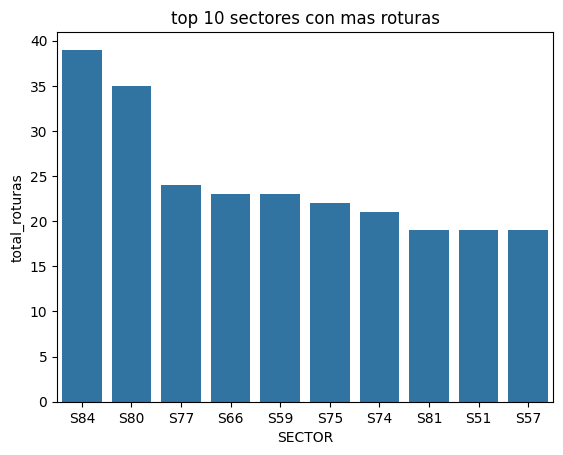

In [190]:
rank_rot = df_roturas.group_by("SECTOR").agg(pl.len().alias("total_roturas")).sort("total_roturas", descending=True)
rank_fug = df_fugas.group_by("SECTOR").agg(pl.len().alias("total_fugas")).sort("total_fugas", descending=True)

# grafico
sns.barplot(data=rank_rot.head(10).to_pandas(), x="SECTOR", y="total_roturas")
plt.title("top 10 sectores con mas roturas")
plt.show()

### Cálculo del tiempo de reparación

In [191]:
# roturas
#df2_sec = df2_sec.with_columns(
#    datetime_inicio=pl.col("fecha_inicio").dt.combine(pl.col("hora_inicio").dt.time()),
#    datetime_fin=pl.col("fecha_fin").dt.combine(pl.col("hora_fin").dt.time()),
#).with_columns(
#    duracion=pl.col("datetime_fin") - pl.col("datetime_inicio")
#)
#df2_sec = df2_sec.drop(["fecha_inicio", "hora_inicio", "fecha_fin", "hora_fin"])


df_rot_t = df_roturas.with_columns([
    pl.col("hora_inicio").dt.time().alias("h_i"),
    pl.col("hora_fin").dt.time().alias("h_f")
]).with_columns([
    (pl.col("fecha_inicio").dt.combine(pl.col("h_i"))).alias("t1"),
    (pl.col("fecha_fin").dt.combine(pl.col("h_f"))).alias("t2")
]).with_columns(
    ((pl.col("t2") - pl.col("t1")).dt.total_seconds() / 3600).alias("horas")
).drop_nulls("horas")

prom_rot_sector = df_rot_t.group_by("SECTOR").agg(pl.col("horas").mean().alias("promedio_horas"))
total_prom_rot = pl.DataFrame({"SECTOR": ["TOTAL"], "promedio_horas": [df_rot_t["horas"].mean()]})
prom_rot_final = pl.concat([prom_rot_sector, total_prom_rot])

In [192]:
# fugas
df_fug_t = df_fugas.with_columns([
    pl.col("hora_inicio").dt.time().alias("h_i"),
    pl.col("hora_fin").dt.time().alias("h_f")
]).with_columns([
    (pl.col("fecha_inicio").dt.combine(pl.col("h_i"))).alias("t1"),
    (pl.col("fecha_fin").dt.combine(pl.col("h_f"))).alias("t2")
]).with_columns(
    ((pl.col("t2") - pl.col("t1")).dt.total_seconds() / 3600).alias("horas")
).drop_nulls("horas")

prom_fug_sector = df_fug_t.group_by("SECTOR").agg(pl.col("horas").mean().alias("promedio_horas"))
total_prom_fug = pl.DataFrame({"SECTOR": ["TOTAL"], "promedio_horas": [df_fug_t["horas"].mean()]})
prom_fug_final = pl.concat([prom_fug_sector, total_prom_fug])

### Normalización de casos

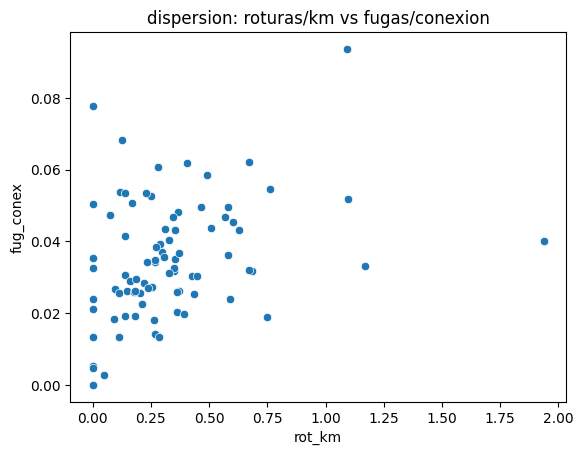

In [193]:
df_redes = df_redes.rename({"Conexiones": "conex", "red_distribucion": "m_dist"})
df_merged = df_redes.join(rank_rot, on="SECTOR", how="left").join(rank_fug, on="SECTOR", how="left").fill_null(0)

df_merged = df_merged.with_columns([
    (pl.col("total_roturas") / (pl.col("m_dist") / 1000)).alias("rot_km"),
    (pl.col("total_fugas") / pl.col("conex")).alias("fug_conex")
])

# unimos con caudal promedio
df_clasif = df_merged.join(df_cau.select(["SECTOR", "PROMEDIO"]), on="SECTOR", how="left").rename({"PROMEDIO": "caudal_prom"})

sns.scatterplot(data=df_clasif.to_pandas(), x='rot_km', y='fug_conex')
plt.title('dispersion: roturas/km vs fugas/conexion')
plt.show()

### Análisis de agrupamiento

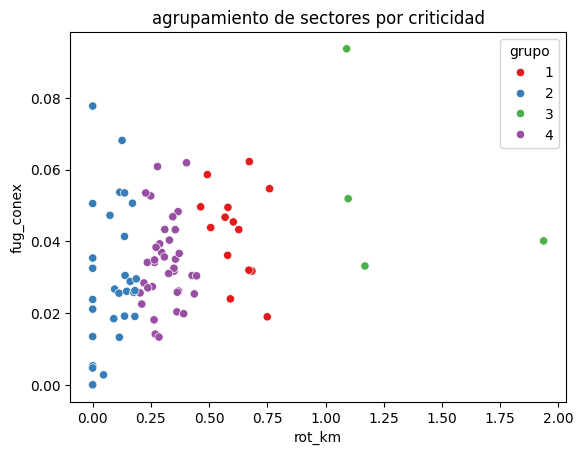

In [ ]:
km = KMeans(n_clusters=4, random_state=42)
coords_cluster = df_clasif.select(["rot_km", "fug_conex"]).to_numpy()
df_clasif = df_clasif.with_columns(pl.Series("grupo", km.fit_predict(coords_cluster) + 1))

# grafico
sns.scatterplot(data=df_clasif.to_pandas(), x="rot_km", y="fug_conex", hue="grupo", palette="Set1")
plt.title("agrupamiento sectores")
plt.show()

## Reto 3: Calculo de la senda optima de reparaciones